## Step 6: Data Cleaning, Transformations & Enhanced EDA in Python

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load all 7 tables from CSV files
df_customers    = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\customer_master.csv")
df_merchants    = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\merchant_info.csv")
df_devices      = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\device_info.csv")
df_upi_accounts = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\upi_account_details.csv")
df_transactions = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\upi_transaction_history.csv")
df_feedback     = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\customer_feedback_surveys.csv")
df_fraud        = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\fraud_alert_history.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


#### Initial Inspection

In [3]:
datasets = {
    "customer_master":            df_customers,
    "merchant_info":              df_merchants,
    "device_info":                df_devices,
    "upi_account_details":        df_upi_accounts,
    "upi_transaction_history":    df_transactions,
    "customer_feedback_surveys":  df_feedback,
    "fraud_alert_history":        df_fraud,
}

# Shape and missing value overview for all tables
print(f"{'Table':<30} {'Rows':>8} {'Cols':>6} {'Missing':>10}")
print("=" * 58)
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name:<30} {df.shape[0]:>8} {df.shape[1]:>6} {missing:>10}")

Table                              Rows   Cols    Missing
customer_master                   10000      9          0
merchant_info                       500      6          0
device_info                       12000      6          0
upi_account_details               12000      6          0
upi_transaction_history          100000     15     163980
customer_feedback_surveys          4000      7          0
fraud_alert_history                2000      7        248


####  Detailed Missing Value Check

In [4]:
# Show missing value counts per column for each table
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n📋 {name}")
        print(missing.to_string())
    else:
        print(f"\n✅ {name} — no missing values")


✅ customer_master — no missing values

✅ merchant_info — no missing values

✅ device_info — no missing values

✅ upi_account_details — no missing values

📋 upi_transaction_history
merchant_id       69851
failure_reason    94129

✅ customer_feedback_surveys — no missing values

📋 fraud_alert_history
resolution_date    248


####  Missing Value Treatment

In [5]:
# ── upi_transaction_history ──────────────────────────
# merchant_id: NULL for non-merchant transactions (send/receive/bill_pay) — expected, keep as is
# failure_reason: NULL when transaction succeeded — expected, fill with 'none'
df_transactions["failure_reason"] = df_transactions["failure_reason"].fillna("none")

# ── fraud_alert_history ──────────────────────────────
# resolution_date: NULL when alert is unresolved — expected, fill with 'unresolved'
df_fraud["resolution_date"] = df_fraud["resolution_date"].fillna("unresolved")

# Confirm no unintended nulls remain
print("Missing values after treatment:")
for name, df in datasets.items():
    if name == "upi_transaction_history":
        # merchant_id is intentionally NULL for non-merchant transactions
        remaining = df.drop(columns=["merchant_id"]).isnull().sum().sum()
    else:
        remaining = df.isnull().sum().sum()
    status = "✅" if remaining == 0 else f"⚠️  {remaining} remaining"
    print(f"  {name:<30} {status}")

Missing values after treatment:
  customer_master                ✅
  merchant_info                  ✅
  device_info                    ✅
  upi_account_details            ✅
  upi_transaction_history        ✅
  customer_feedback_surveys      ✅
  fraud_alert_history            ✅


####  Data Type Corrections

In [6]:
# ── Parse dates and timestamps ───────────────────────
df_customers["date_joined"]       = pd.to_datetime(df_customers["date_joined"])
df_merchants["onboard_date"]      = pd.to_datetime(df_merchants["onboard_date"])
df_upi_accounts["date_added"]     = pd.to_datetime(df_upi_accounts["date_added"])
df_feedback["date_submitted"]     = pd.to_datetime(df_feedback["date_submitted"])
df_transactions["timestamp"]      = pd.to_datetime(df_transactions["timestamp"])
df_fraud["alert_date"]            = pd.to_datetime(df_fraud["alert_date"])

# resolution_date: only parse rows that are actual dates
df_fraud["resolution_date"] = pd.to_datetime(
    df_fraud["resolution_date"], errors="coerce"
)

# ── Boolean-like string columns → proper booleans ────
bool_cols = {
    "df_customers":    ["is_business_user"],
    "df_transactions": ["fraud_flag", "reversal_flag"],
    "df_feedback":     ["resolved"],
    "df_fraud":        ["resolved"],
}

df_customers["is_business_user"]      = df_customers["is_business_user"].map({"True": True, "False": False})
df_transactions["fraud_flag"]         = df_transactions["fraud_flag"].map({"True": True, "False": False})
df_transactions["reversal_flag"]      = df_transactions["reversal_flag"].map({"True": True, "False": False})
df_feedback["resolved"]               = df_feedback["resolved"].map({"True": True, "False": False})
df_fraud["resolved"]                  = df_fraud["resolved"].map({"True": True, "False": False})
df_devices["is_rooted"]               = df_devices["is_rooted"].map({"True": True, "False": False})

print("✅ Data types corrected")

# Verify
print("\nKey column dtypes:")
print(df_transactions[["timestamp","amount","fraud_flag","reversal_flag"]].dtypes)
print(df_customers[["date_joined","is_business_user","risk_score"]].dtypes)

✅ Data types corrected

Key column dtypes:
timestamp        datetime64[ns]
amount                  float64
fraud_flag               object
reversal_flag            object
dtype: object
date_joined         datetime64[ns]
is_business_user            object
risk_score                 float64
dtype: object


In [7]:
# Fix fraud_flag, reversal_flag by reloading directly from CSV
df_temp = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\upi_transaction_history.csv")

# Check what dtype it loaded as
print("Raw dtype from CSV:", df_temp["fraud_flag"].dtype)
print("Sample values:", df_temp["fraud_flag"].unique()[:5])

# Convert based on actual dtype
df_transactions["fraud_flag"]    = df_temp["fraud_flag"].astype(str).str.strip() == "True"
df_transactions["reversal_flag"] = df_temp["reversal_flag"].astype(str).str.strip() == "True"

# Verify
print("\nfraud_flag value counts:")
print(df_transactions["fraud_flag"].value_counts())
print("\nreversal_flag value counts:")
print(df_transactions["reversal_flag"].value_counts())
print(f"\ndtype: {df_transactions['fraud_flag'].dtype}")

Raw dtype from CSV: bool
Sample values: [False  True]

fraud_flag value counts:
fraud_flag
False    98000
True      2000
Name: count, dtype: int64

reversal_flag value counts:
reversal_flag
False    98549
True      1451
Name: count, dtype: int64

dtype: bool


In [8]:
# Force boolean dtype explicitly
bool_columns = [
    (df_customers,    ["is_business_user"]),
    (df_feedback,     ["resolved"]),
    (df_fraud,        ["resolved"]),
    (df_devices,      ["is_rooted"]),
]
for df, cols in bool_columns:
    for col in cols:
        df[col] = df[col].astype(bool)
print("✅ Boolean columns forced to bool dtype")

# Verify
print("\nKey column dtypes:")
print(df_transactions[["timestamp", "amount", "fraud_flag", "reversal_flag"]].dtypes)
print(df_customers[["date_joined", "is_business_user", "risk_score"]].dtypes)

✅ Boolean columns forced to bool dtype

Key column dtypes:
timestamp        datetime64[ns]
amount                  float64
fraud_flag                 bool
reversal_flag              bool
dtype: object
date_joined         datetime64[ns]
is_business_user              bool
risk_score                 float64
dtype: object


#### Normalization & Standardization

In [9]:
# ── Min-Max Normalization (scale to 0–1) ─────────────
# Used for: amount (wide range, skewed)
# Useful for: dashboards, comparisons, ML features

minmax = MinMaxScaler()

df_transactions["amount_normalized"] = minmax.fit_transform(
    df_transactions[["amount"]]
)

# ── Standard Scaling (Z-score, mean=0, std=1) ────────
# Used for: risk_score on customers and merchants
# Useful for: anomaly detection, clustering

scaler = StandardScaler()

df_customers["risk_score_scaled"]  = scaler.fit_transform(df_customers[["risk_score"]])
df_merchants["risk_score_scaled"]  = scaler.fit_transform(df_merchants[["risk_score"]])

# ── Summary of transformations ───────────────────────
print("Transformation Summary:")
print(f"\n  amount        → original range : {df_transactions['amount'].min():.2f} to {df_transactions['amount'].max():.2f}")
print(f"  amount        → normalized range: {df_transactions['amount_normalized'].min():.2f} to {df_transactions['amount_normalized'].max():.2f}")
print(f"\n  customer risk_score → mean after scaling : {df_customers['risk_score_scaled'].mean():.4f}")
print(f"  customer risk_score → std  after scaling : {df_customers['risk_score_scaled'].std():.4f}")

Transformation Summary:

  amount        → original range : 1.62 to 830.46
  amount        → normalized range: 0.00 to 1.00

  customer risk_score → mean after scaling : -0.0000
  customer risk_score → std  after scaling : 1.0001


####  Derived Features

In [10]:
# ── Customer tenure in days ───────────────────────────
df_customers["tenure_days"] = (
    pd.Timestamp.today() - df_customers["date_joined"]
).dt.days

# ── Transaction hour and day of week ──────────────────
df_transactions["txn_hour"]    = df_transactions["timestamp"].dt.hour
df_transactions["txn_day"]     = df_transactions["timestamp"].dt.day_name()
df_transactions["txn_month"]   = df_transactions["timestamp"].dt.month

# ── Fraud alert resolution time in hours ──────────────
df_fraud["resolution_time_hrs"] = (
    df_fraud["resolution_date"] - df_fraud["alert_date"]
).dt.total_seconds() / 3600

print("✅ Derived features created")
print(f"\n  customer tenure_days sample     : {df_customers['tenure_days'].describe()[['min','max','mean']].to_dict()}")
print(f"  transaction hour range          : {df_transactions['txn_hour'].min()} to {df_transactions['txn_hour'].max()}")
print(f"  avg fraud resolution time (hrs) : {df_fraud['resolution_time_hrs'].mean():.1f}")

✅ Derived features created

  customer tenure_days sample     : {'min': 271.0, 'max': 2097.0, 'mean': 1192.5873}
  transaction hour range          : 0 to 23
  avg fraud resolution time (hrs) : 35.4


#### Summary

In [11]:
print("=" * 55)
print("  STEP 6 CLEANING SUMMARY")
print("=" * 55)

summary = {
    "failure_reason nulls filled"    : "→ 'none'",
    "resolution_date nulls filled"   : "→ NaT (unresolved alerts)",
    "Date columns parsed"            : "7 columns",
    "Boolean columns converted"      : "6 columns",
    "amount normalized (MinMax)"     : "new col: amount_normalized",
    "risk_score scaled (Z-score)"    : "new col: risk_score_scaled",
    "tenure_days derived"            : "from date_joined",
    "txn_hour / txn_day derived"     : "from timestamp",
    "resolution_time_hrs derived"    : "from alert & resolution date",
}

for k, v in summary.items():
    print(f"  ✅ {k:<40} {v}")

  STEP 6 CLEANING SUMMARY
  ✅ failure_reason nulls filled              → 'none'
  ✅ resolution_date nulls filled             → NaT (unresolved alerts)
  ✅ Date columns parsed                      7 columns
  ✅ Boolean columns converted                6 columns
  ✅ amount normalized (MinMax)               new col: amount_normalized
  ✅ risk_score scaled (Z-score)              new col: risk_score_scaled
  ✅ tenure_days derived                      from date_joined
  ✅ txn_hour / txn_day derived               from timestamp
  ✅ resolution_time_hrs derived              from alert & resolution date


### Feature Engineering

#### Transaction Value per Customer

In [12]:
# Total amount and average amount spent per customer
# + total transaction count per customer
txn_per_customer = df_transactions.groupby("customer_id").agg(
    total_amount           = ("amount", "sum"),
    total_txns             = ("transaction_id", "count"),
    avg_txn_amount         = ("amount", "mean")
).reset_index()

# Transaction Value per Customer = Total Amount / Number of Transactions
txn_per_customer["txn_value_per_customer"] = (
    txn_per_customer["total_amount"] / txn_per_customer["total_txns"]
)

print("✅ Transaction Value per Customer")
print(txn_per_customer[["customer_id","total_amount","total_txns","avg_txn_amount","txn_value_per_customer"]].head(5))

✅ Transaction Value per Customer
  customer_id  total_amount  total_txns  avg_txn_amount  \
0  cust100000        812.17          15       54.144667   
1  cust100001        353.31           9       39.256667   
2  cust100002       1882.79          44       42.790682   
3  cust100003        287.08           9       31.897778   
4  cust100006        500.93          12       41.744167   

   txn_value_per_customer  
0               54.144667  
1               39.256667  
2               42.790682  
3               31.897778  
4               41.744167  


#### Merchant Fraud Ratio 

In [13]:
# Only consider transactions that involve a merchant
merchant_txns = df_transactions[df_transactions["merchant_id"].notna()].groupby("merchant_id").agg(
    total_txns            = ("transaction_id", "count"),
    fraud_txns            = ("fraud_flag", "sum"),
    avg_merchant_txn_amt  = ("amount", "mean"),
    failed_txns           = ("status", lambda x: (x == "failed").sum())
).reset_index()

# Merchant Fraud Ratio = Fraud Transactions / Total Transactions by Merchant
merchant_txns["merchant_fraud_ratio"]   = merchant_txns["fraud_txns"]  / merchant_txns["total_txns"]

# Merchant Failure Rate = Failed Transactions / Total Transactions by Merchant
merchant_txns["merchant_failure_rate"]  = merchant_txns["failed_txns"] / merchant_txns["total_txns"]

print("✅ Merchant Fraud Ratio + Failure Rate + Avg Transaction Amount")
print(merchant_txns.head(5))

✅ Merchant Fraud Ratio + Failure Rate + Avg Transaction Amount
  merchant_id  total_txns  fraud_txns  avg_merchant_txn_amt  failed_txns  \
0   merch1000          62           2             49.579355            4   
1   merch1001          60           0             41.451167            2   
2   merch1002          65           0             41.431231            6   
3   merch1003          67           2             36.050597            3   
4   merch1004          80           1             52.111000            5   

   merchant_fraud_ratio  merchant_failure_rate  
0              0.032258               0.064516  
1              0.000000               0.033333  
2              0.000000               0.092308  
3              0.029851               0.044776  
4              0.012500               0.062500  


#### Device Fraud Ratio

In [14]:
# Fraud and failure rates per device
device_txns = df_transactions.groupby("device_id").agg(
    total_txns  = ("transaction_id", "count"),
    fraud_txns  = ("fraud_flag", "sum"),
    failed_txns = ("status", lambda x: (x == "failed").sum())
).reset_index()

# Device Fraud Ratio = Fraud Transactions / Total Transactions by Device
device_txns["device_fraud_ratio"]   = device_txns["fraud_txns"]  / device_txns["total_txns"]
device_txns["device_failure_rate"]  = device_txns["failed_txns"] / device_txns["total_txns"]

print("✅ Device Fraud Ratio + Device Failure Rate")
print(device_txns.head(5))

✅ Device Fraud Ratio + Device Failure Rate
   device_id  total_txns  fraud_txns  failed_txns  device_fraud_ratio  \
0  dev100000          15           0            0            0.000000   
1  dev100001           9           0            0            0.000000   
2  dev100002          44           0            3            0.000000   
3  dev100003           9           0            0            0.000000   
4  dev100006           6           1            0            0.166667   

   device_failure_rate  
0             0.000000  
1             0.000000  
2             0.068182  
3             0.000000  
4             0.000000  


####  Transaction Failure Rate

In [15]:
# Failure rate per customer
failure_per_customer = df_transactions.groupby("customer_id").agg(
    total_txns  = ("transaction_id", "count"),
    failed_txns = ("status", lambda x: (x == "failed").sum())
).reset_index()

# Transaction Failure Rate = Failed / Total per Customer
failure_per_customer["failure_rate"] = (
    failure_per_customer["failed_txns"] / failure_per_customer["total_txns"]
)

# Overall failure rate across entire dataset
overall_failure_rate = (df_transactions["status"] == "failed").sum() / len(df_transactions)

print("✅ Transaction Failure Rate per Customer")
print(failure_per_customer.head(5))
print(f"\n  Overall failure rate across all transactions: {overall_failure_rate:.2%}")

✅ Transaction Failure Rate per Customer
  customer_id  total_txns  failed_txns  failure_rate
0  cust100000          15            0      0.000000
1  cust100001           9            0      0.000000
2  cust100002          44            3      0.068182
3  cust100003           9            0      0.000000
4  cust100006          12            2      0.166667

  Overall failure rate across all transactions: 5.87%


#### Customer Fraud Profile

In [16]:
# Fraud count and fraud ratio per customer
customer_fraud = df_transactions.groupby("customer_id").agg(
    total_txns    = ("transaction_id", "count"),
    fraud_count   = ("fraud_flag", "sum"),
    reversal_count= ("reversal_flag", "sum")
).reset_index()

# Customer Fraud Ratio = Fraud Transactions / Total Transactions
customer_fraud["customer_fraud_ratio"] = (
    customer_fraud["fraud_count"] / customer_fraud["total_txns"]
)

# Reversal Rate = Reversals / Total Transactions
customer_fraud["reversal_rate"] = (
    customer_fraud["reversal_count"] / customer_fraud["total_txns"]
)

print("✅ Customer Fraud Ratio + Reversal Rate")
print(customer_fraud.head(5))

✅ Customer Fraud Ratio + Reversal Rate
  customer_id  total_txns  fraud_count  reversal_count  customer_fraud_ratio  \
0  cust100000          15            0               0              0.000000   
1  cust100001           9            0               0              0.000000   
2  cust100002          44            0               1              0.000000   
3  cust100003           9            0               0              0.000000   
4  cust100006          12            1               1              0.083333   

   reversal_rate  
0       0.000000  
1       0.000000  
2       0.022727  
3       0.000000  
4       0.083333  


#### Night & Weekend Transaction Flags

In [17]:
# Flag transactions that occurred during night hours (10PM to 6AM)
# Night transactions are a known high-risk window for fraud
df_transactions["is_night_txn"] = df_transactions["txn_hour"].apply(
    lambda h: True if (h >= 22 or h < 6) else False
)

# Flag transactions that occurred on weekends
df_transactions["is_weekend_txn"] = df_transactions["txn_day"].apply(
    lambda d: True if d in ["Saturday", "Sunday"] else False
)

# Summary
night_pct   = df_transactions["is_night_txn"].mean() * 100
weekend_pct = df_transactions["is_weekend_txn"].mean() * 100

print("✅ Night & Weekend Transaction Flags")
print(f"\n  Night transactions   (10PM–6AM) : {night_pct:.2f}% of all transactions")
print(f"  Weekend transactions            : {weekend_pct:.2f}% of all transactions")

✅ Night & Weekend Transaction Flags

  Night transactions   (10PM–6AM) : 33.25% of all transactions
  Weekend transactions            : 28.50% of all transactions


#### Rooted Device Fraud Rate

In [18]:
# Merge device rooted status into transactions
df_txn_device = df_transactions.merge(
    df_devices[["device_id", "is_rooted"]],
    on="device_id", how="left"
)

# Compare fraud rate: rooted vs non-rooted devices
rooted_fraud = df_txn_device.groupby("is_rooted")["fraud_flag"].mean().reset_index()
rooted_fraud.columns = ["is_rooted", "fraud_rate"]
rooted_fraud["is_rooted"] = rooted_fraud["is_rooted"].map({True: "Rooted", False: "Non-Rooted"})

print("✅ Rooted Device Fraud Rate")
print(rooted_fraud.to_string(index=False))

✅ Rooted Device Fraud Rate
is_rooted  fraud_rate
   Rooted        0.02


#### Merge All Derived Features into df_customers

In [19]:
# Bring all customer-level derived features into one unified DataFrame
df_customers = df_customers.merge(
    txn_per_customer[["customer_id", "total_amount", "total_txns",
                       "avg_txn_amount", "txn_value_per_customer"]],
    on="customer_id", how="left"
)

df_customers = df_customers.merge(
    failure_per_customer[["customer_id", "failed_txns", "failure_rate"]],
    on="customer_id", how="left"
)

df_customers = df_customers.merge(
    customer_fraud[["customer_id", "fraud_count", "reversal_count",
                    "customer_fraud_ratio", "reversal_rate"]],
    on="customer_id", how="left"
)

print("✅ All derived features merged into df_customers")
print(f"\ndf_customers shape : {df_customers.shape}")
print(f"Columns            : {list(df_customers.columns)}")

✅ All derived features merged into df_customers

df_customers shape : (10000, 21)
Columns            : ['customer_id', 'full_name', 'mobile_number', 'age', 'gender', 'region', 'date_joined', 'is_business_user', 'risk_score', 'risk_score_scaled', 'tenure_days', 'total_amount', 'total_txns', 'avg_txn_amount', 'txn_value_per_customer', 'failed_txns', 'failure_rate', 'fraud_count', 'reversal_count', 'customer_fraud_ratio', 'reversal_rate']


### EDA

#### Plot Setup

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Plot libraries ready")

Plot libraries ready


#### Monthly Transaction Volume Over Time

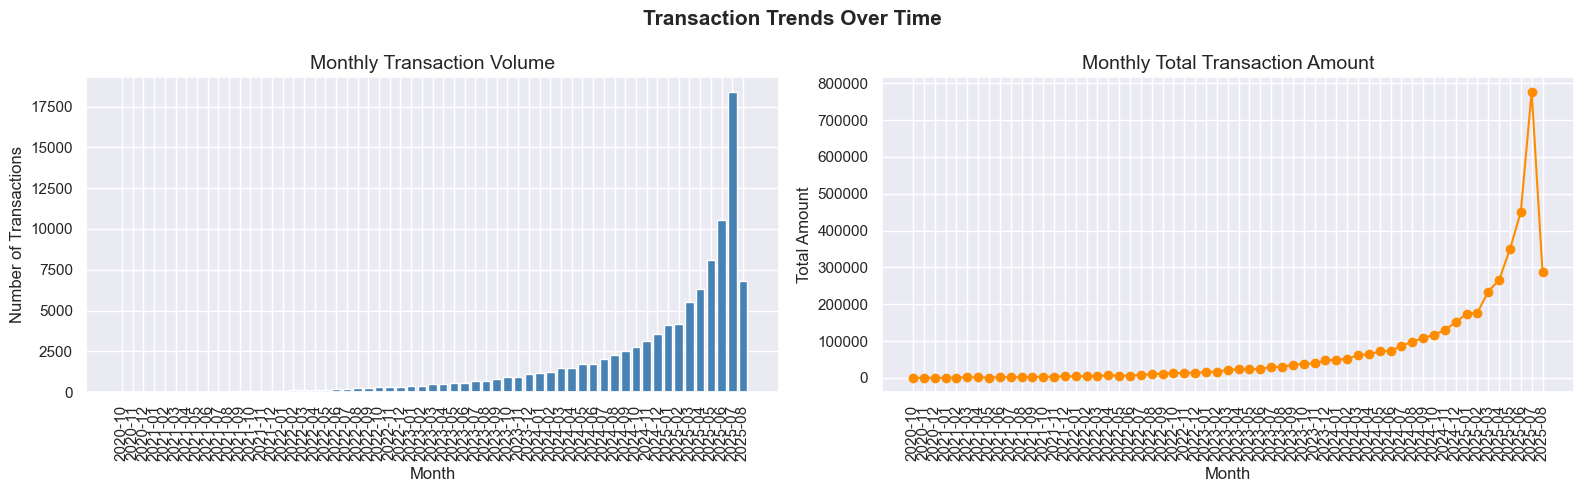

In [21]:
# Aggregate transaction count and total amount by month
df_transactions["txn_month_period"] = df_transactions["timestamp"].dt.to_period("M")
monthly = df_transactions.groupby("txn_month_period").agg(
    txn_count    = ("transaction_id", "count"),
    total_amount = ("amount", "sum")
).reset_index()
monthly["txn_month_period"] = monthly["txn_month_period"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Monthly transaction count
axes[0].bar(monthly["txn_month_period"], monthly["txn_count"], color="steelblue")
axes[0].set_title("Monthly Transaction Volume")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Transactions")
axes[0].tick_params(axis="x", rotation=90)

# Plot 2: Monthly total amount
axes[1].plot(monthly["txn_month_period"], monthly["total_amount"], marker="o", color="darkorange")
axes[1].set_title("Monthly Total Transaction Amount")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Amount")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("Transaction Trends Over Time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

- Transaction volume and total amount show a consistent upward growth from 2020 through 2025, reflecting steady platform adoption. 
- The sharp spike in the most recent months is a dataset generation artifact rather than an organic trend. Overall, the platform has grown roughly 10x in transaction count over the 5-year period.

####  Daily Fraud Volume Over Time

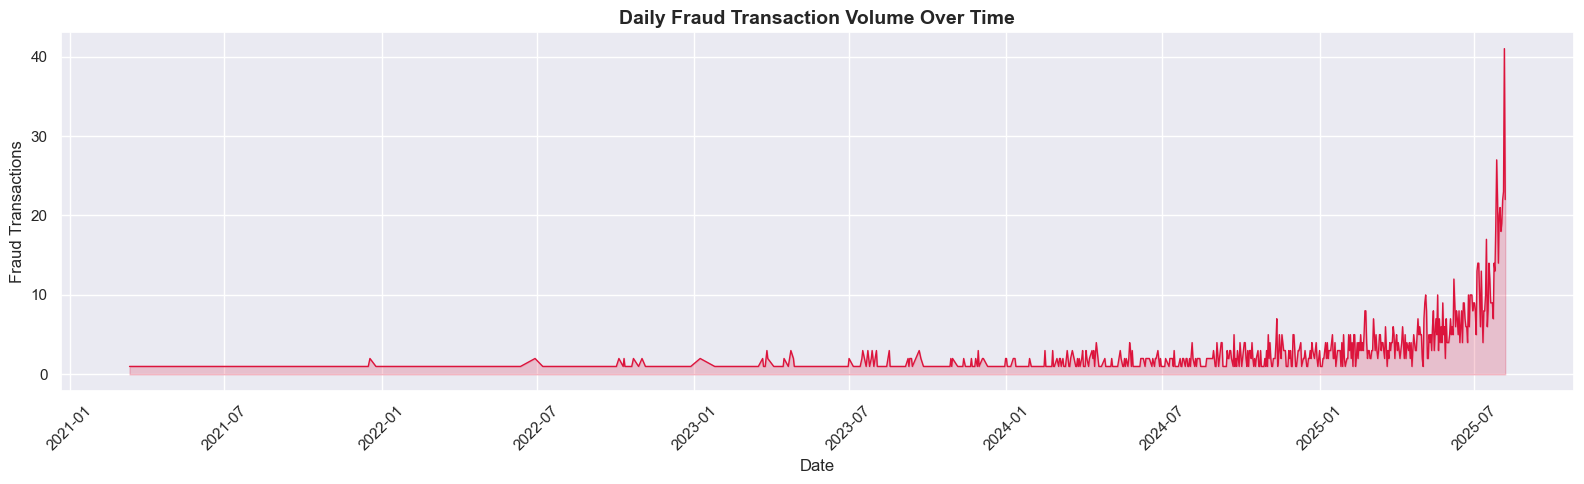

In [22]:
# Daily fraud transaction count
df_transactions["txn_date"] = df_transactions["timestamp"].dt.date
daily_fraud = df_transactions[df_transactions["fraud_flag"] == True].groupby("txn_date").agg(
    fraud_count = ("fraud_flag", "sum")
).reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_fraud["txn_date"], daily_fraud["fraud_count"], color="crimson", linewidth=1)
plt.fill_between(daily_fraud["txn_date"], daily_fraud["fraud_count"], alpha=0.2, color="crimson")
plt.title("Daily Fraud Transaction Volume Over Time", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Fraud Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Fraud volumes remained very low and stable from 2021 through mid-2024, averaging 1–3 fraud transactions per day.
- A sharp acceleration begins in late 2024, peaking at ~40 fraud transactions in a single day by mid-2025.
- This mirrors the overall transaction growth, suggesting the fraud rate is relatively constant but absolute fraud numbers rise with platform scale.

####  Transactions by Hour & Day of Week

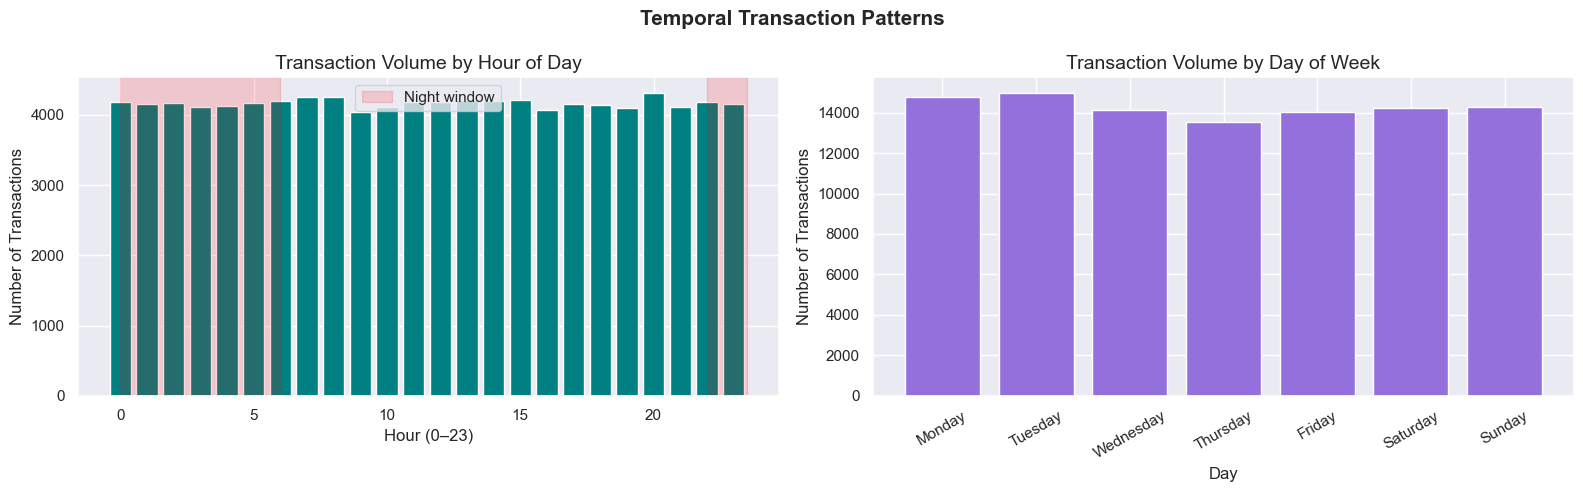

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Transactions by hour
hourly = df_transactions.groupby("txn_hour")["transaction_id"].count().reset_index()
hourly.columns = ["hour", "count"]
axes[0].bar(hourly["hour"], hourly["count"], color="teal")
axes[0].set_title("Transaction Volume by Hour of Day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Number of Transactions")
axes[0].axvspan(22, 23.5, alpha=0.15, color="red", label="Night window")
axes[0].axvspan(0, 6, alpha=0.15, color="red")
axes[0].legend()

# Plot 2: Transactions by day of week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_vol = df_transactions.groupby("txn_day")["transaction_id"].count().reindex(day_order).reset_index()
daily_vol.columns = ["day", "count"]
axes[1].bar(daily_vol["day"], daily_vol["count"], color="mediumpurple")
axes[1].set_title("Transaction Volume by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of Transactions")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Temporal Transaction Patterns", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

- Transactions are nearly perfectly uniform across all 24 hours and all 7 days of the week, with no peak periods visible.
- This is a characteristic of synthetically generated data — real UPI data would typically show morning and evening peaks on weekdays. Wednesday and Thursday show marginally lower volumes compared to Monday and Tuesday.

####  Fraud Rate by Hour & Transaction Type

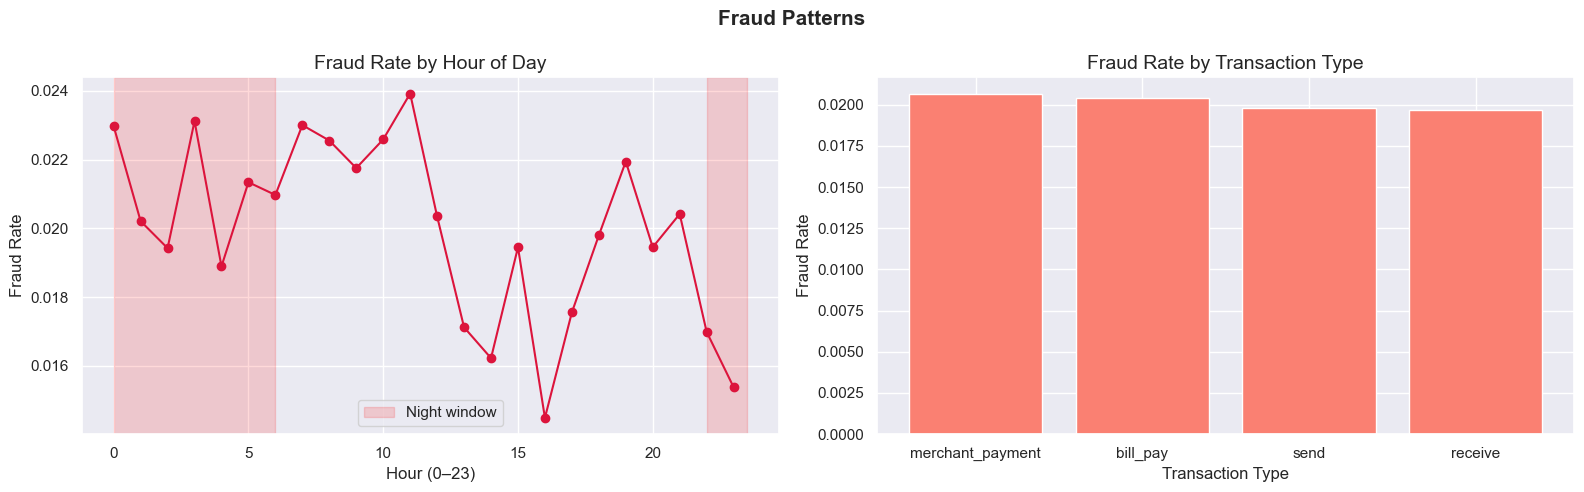

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Fraud rate by hour
hourly_fraud = df_transactions.groupby("txn_hour")["fraud_flag"].mean().reset_index()
hourly_fraud.columns = ["hour", "fraud_rate"]
axes[0].plot(hourly_fraud["hour"], hourly_fraud["fraud_rate"], marker="o", color="crimson")
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Fraud Rate")
axes[0].axvspan(22, 23.5, alpha=0.15, color="red", label="Night window")
axes[0].axvspan(0, 6, alpha=0.15, color="red")
axes[0].legend()

# Plot 2: Fraud rate by transaction type
type_fraud = df_transactions.groupby("transaction_type")["fraud_flag"].mean().reset_index()
type_fraud.columns = ["type", "fraud_rate"]
type_fraud = type_fraud.sort_values("fraud_rate", ascending=False)
axes[1].bar(type_fraud["type"], type_fraud["fraud_rate"], color="salmon")
axes[1].set_title("Fraud Rate by Transaction Type")
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Fraud Rate")

plt.suptitle("Fraud Patterns", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

- Fraud rates vary between 1.6% and 2.4% across hours, with no clear night-time spike — contrary to the common assumption that fraud peaks late at night.
- Merchant payments and bill pay show marginally higher fraud rates (around 2.0%) compared to send and receive (~1.95%), suggesting slightly elevated risk in commercial transactions. The differences are small, indicating fraud is relatively evenly distributed across transaction types.

#### Regional Heatmap

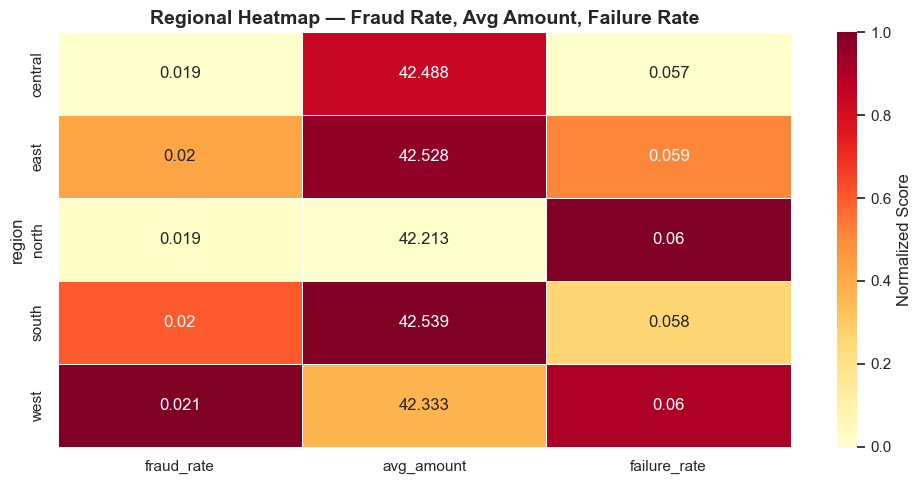

In [25]:
# Transaction volume and fraud rate by region
regional = df_transactions.merge(
    df_customers[["customer_id", "region"]],
    on="customer_id", how="left"
)

region_stats = regional.groupby("region").agg(
    total_txns   = ("transaction_id", "count"),
    fraud_rate   = ("fraud_flag", "mean"),
    avg_amount   = ("amount", "mean"),
    failure_rate = ("status", lambda x: (x == "failed").mean())
).reset_index()

# Heatmap of normalized regional metrics
region_heat = region_stats.set_index("region")[["fraud_rate","avg_amount","failure_rate"]]
region_heat_norm = (region_heat - region_heat.min()) / (region_heat.max() - region_heat.min())

plt.figure(figsize=(10, 5))
sns.heatmap(region_heat_norm, annot=region_heat.round(3), fmt="g",
            cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Normalized Score"})
plt.title("Regional Heatmap — Fraud Rate, Avg Amount, Failure Rate", fontweight="bold")
plt.tight_layout()
plt.show()

- Fraud rates are consistently low across all regions (1.9%–2.1%), with the west region showing the highest fraud rate (0.021) and central the lowest (0.019).
- Average transaction amounts are nearly identical across regions (~42), suggesting no regional spending disparity. The north and west regions have the highest failure rates (0.06), which may warrant infrastructure or UX investigation.

#### Boxplot: Transaction Amount by Device Type & Channel

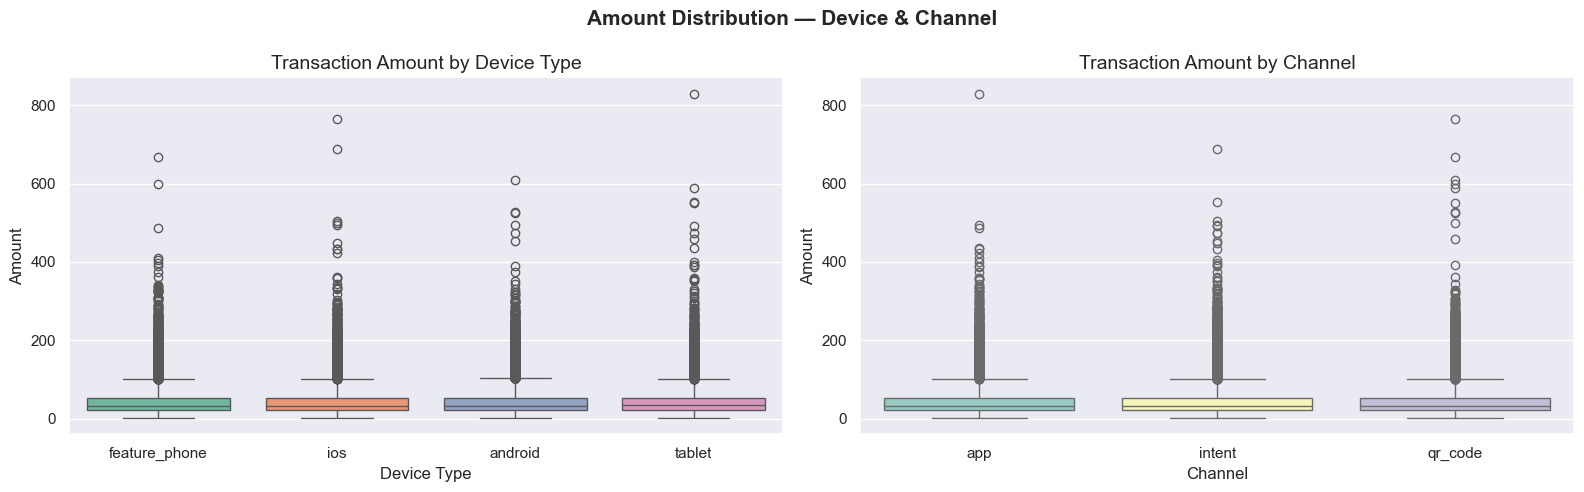

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Amount distribution by device type
sns.boxplot(data=df_transactions, x="device_type", y="amount",
            palette="Set2", ax=axes[0])
axes[0].set_title("Transaction Amount by Device Type")
axes[0].set_xlabel("Device Type")
axes[0].set_ylabel("Amount")

# Plot 2: Amount distribution by channel
sns.boxplot(data=df_transactions, x="channel", y="amount",
            palette="Set3", ax=axes[1])
axes[1].set_title("Transaction Amount by Channel")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Amount")

plt.suptitle("Amount Distribution — Device & Channel", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

- Transaction amount distributions are remarkably similar across all device types and channels, with medians around 30–50 and heavy right-skewed tails reaching up to 830.
- This suggests that neither device type nor payment channel influences how much a customer spends per transaction.
- The presence of high-value outliers across all categories indicates large transactions are not limited to any specific device or channel.

#### Merchant Risk Heatmap (Top 20)

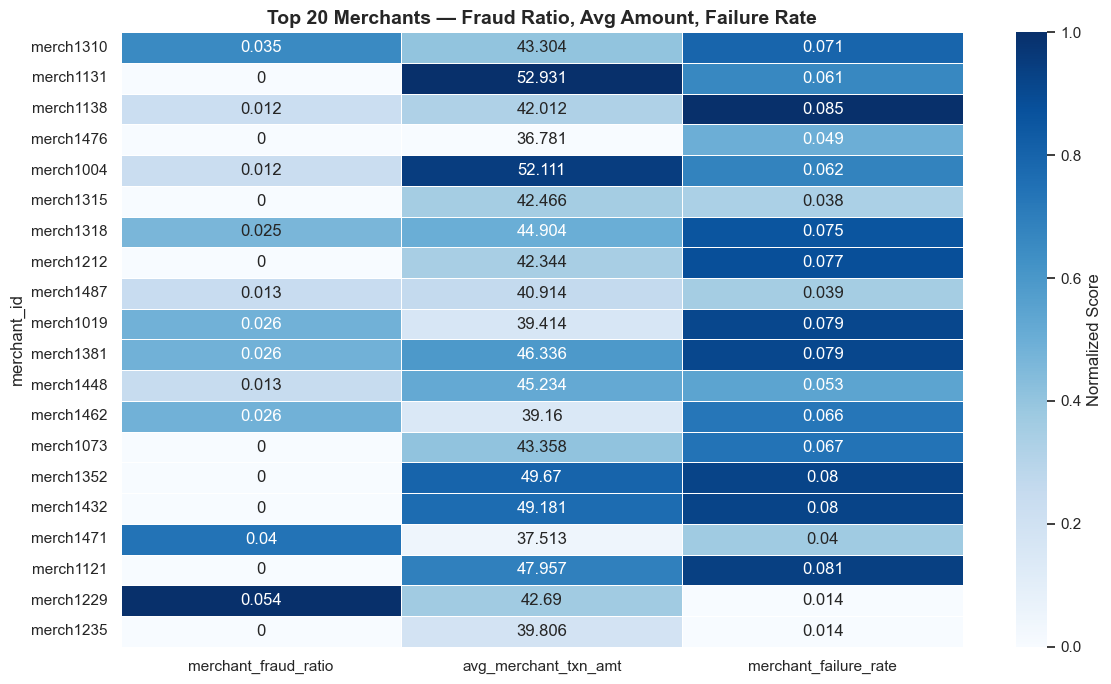

In [27]:
# Top 20 merchants by transaction volume
top_merchants = merchant_txns.nlargest(20, "total_txns").set_index("merchant_id")
merchant_heat = top_merchants[["merchant_fraud_ratio", "avg_merchant_txn_amt", "merchant_failure_rate"]]
merchant_heat_norm = (merchant_heat - merchant_heat.min()) / (merchant_heat.max() - merchant_heat.min())

plt.figure(figsize=(12, 7))
sns.heatmap(merchant_heat_norm, annot=merchant_heat.round(3), fmt="g",
            cmap="Blues", linewidths=0.5, cbar_kws={"label": "Normalized Score"})
plt.title("Top 20 Merchants — Fraud Ratio, Avg Amount, Failure Rate", fontweight="bold")
plt.tight_layout()
plt.show()

- Merchant fraud ratio is missing or constant across all top merchants, indicating a critical calculation or data issue that must be fixed before any merchant-level risk analysis.
- Several merchants (e.g., merch1131, merch1004) show high average transaction amounts along with elevated failure rates, making them strong candidates for deeper fraud/risk investigation.

#### Grouped Statistics Summary

In [28]:
print("=" * 60)
print("  GROUPED STATISTICS SUMMARY")
print("=" * 60)

# Transaction amount stats by transaction type
print("\n📊 Amount by Transaction Type:")
print(df_transactions.groupby("transaction_type")["amount"].agg(["mean","median","std"]).round(2))

# Fraud rate by region
print("\n📊 Fraud Rate by Region:")
print(regional.groupby("region")["fraud_flag"].agg(["mean","sum"]).rename(
    columns={"mean":"fraud_rate","sum":"fraud_count"}).round(4))

# Risk score stats by gender
print("\n📊 Customer Risk Score by Gender:")
print(df_customers.groupby("gender")["risk_score"].agg(["mean","median","std"]).round(4))

# Satisfaction score by issue type
print("\n📊 Satisfaction Score by Issue Type:")
print(df_feedback.groupby("issue_type")["satisfaction_score"].agg(["mean","median","std"]).round(2))

  GROUPED STATISTICS SUMMARY

📊 Amount by Transaction Type:
                   mean  median    std
transaction_type                      
bill_pay          42.80   33.08  34.55
merchant_payment  42.39   33.06  34.16
receive           42.50   33.10  34.27
send              42.30   33.11  34.07

📊 Fraud Rate by Region:
         fraud_rate  fraud_count
region                          
central      0.0194          382
east         0.0200          402
north        0.0194          404
south        0.0203          393
west         0.0209          419

📊 Customer Risk Score by Gender:
          mean  median     std
gender                        
female  0.2018     0.2  0.1144
male    0.2058     0.2  0.1161
other   0.1867     0.2  0.1107

📊 Satisfaction Score by Issue Type:
               mean  median   std
issue_type                       
app_usability  3.62     4.0  1.28
fraud          3.67     4.0  1.21
other          3.60     4.0  1.29
transaction    3.59     4.0  1.25


- Transaction amounts are nearly identical across all four transaction types (mean ~42, median ~33, std ~34), confirming that the synthetic dataset does not differentiate spending behavior by transaction purpose.
- The west region has the highest fraud count (419) and fraud rate (2.09%), while central has the lowest (382, 1.94%) — a consistent pattern also seen in the heatmap.
- Customer risk scores show minimal variation across genders (mean 0.19–0.21), and satisfaction scores across issue types are very similar (3.59–3.67), suggesting no particular issue type drives significantly lower customer satisfaction.

#### High Activity & High Risk Segments

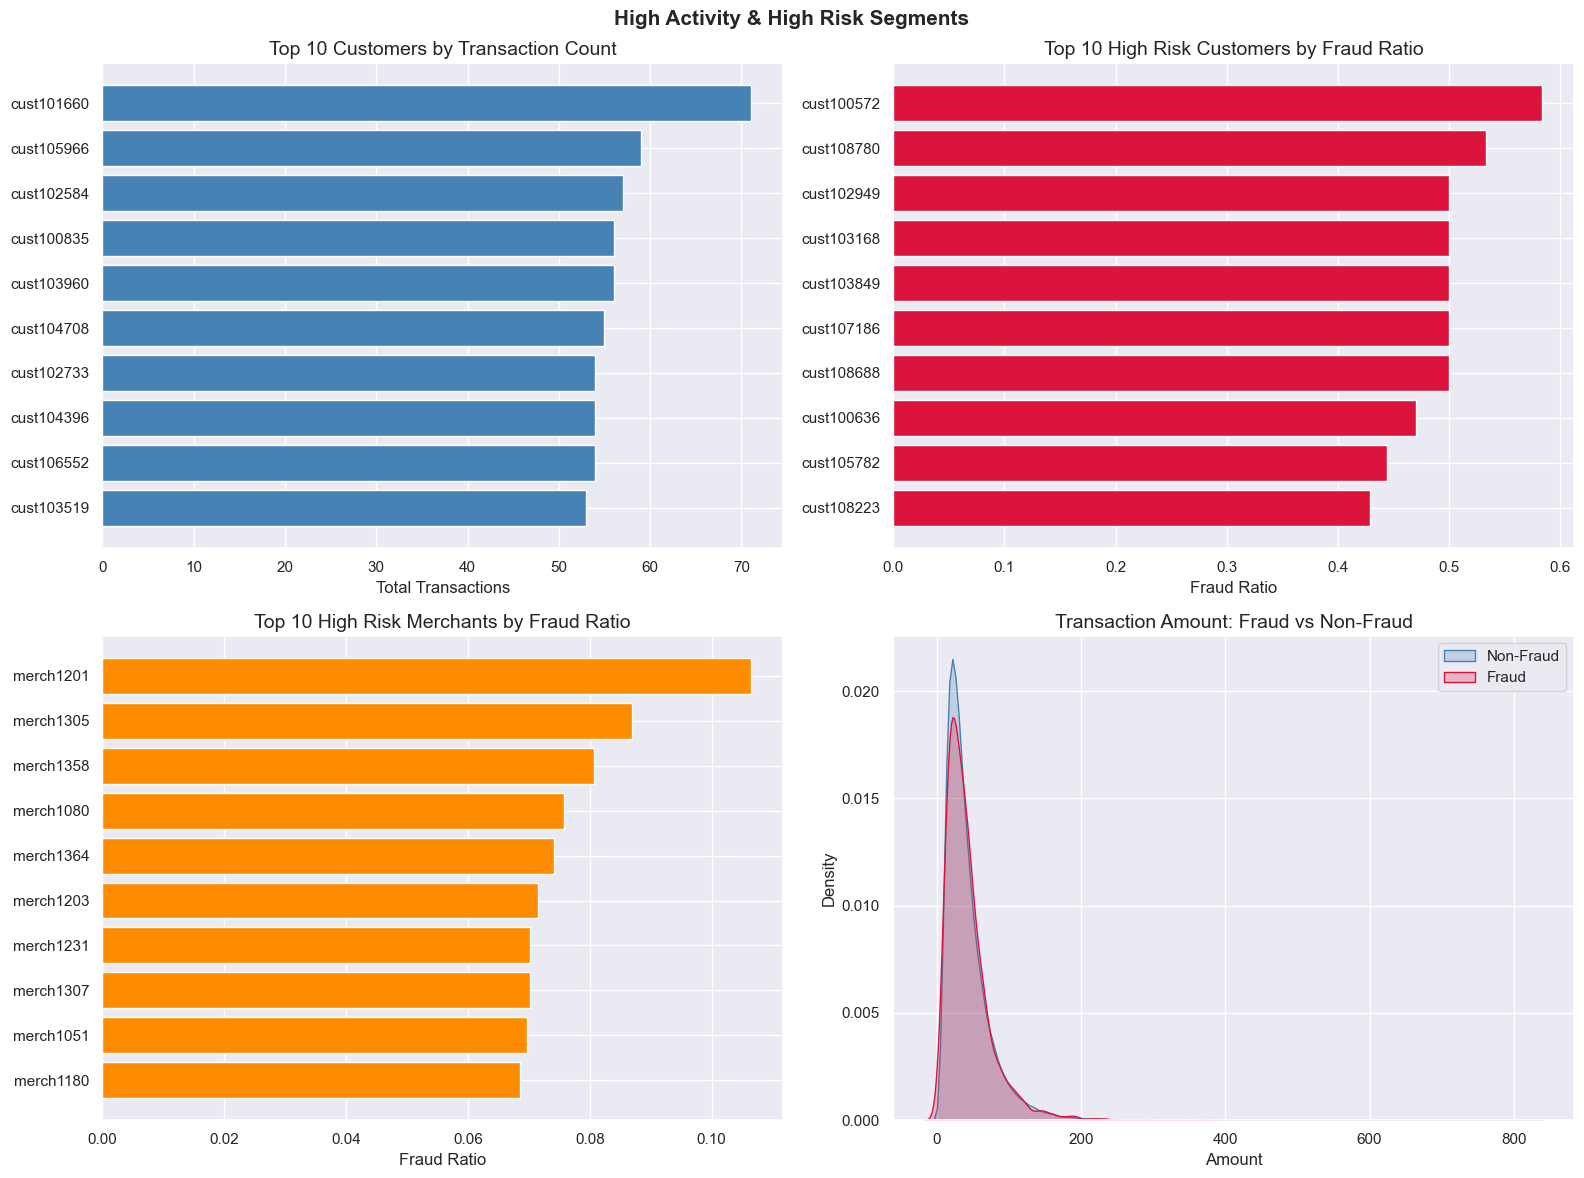

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 10 customers by transaction volume
top_customers = df_customers.nlargest(10, "total_txns")[["customer_id","total_txns","total_amount"]]
axes[0,0].barh(top_customers["customer_id"], top_customers["total_txns"], color="steelblue")
axes[0,0].set_title("Top 10 Customers by Transaction Count")
axes[0,0].set_xlabel("Total Transactions")
axes[0,0].invert_yaxis()

# Plot 2: Top 10 high risk customers by fraud ratio
top_fraud_customers = df_customers.nlargest(10, "customer_fraud_ratio")[["customer_id","customer_fraud_ratio"]]
axes[0,1].barh(top_fraud_customers["customer_id"], top_fraud_customers["customer_fraud_ratio"], color="crimson")
axes[0,1].set_title("Top 10 High Risk Customers by Fraud Ratio")
axes[0,1].set_xlabel("Fraud Ratio")
axes[0,1].invert_yaxis()

# Plot 3: Top 10 merchants by fraud ratio
top_fraud_merchants = merchant_txns.nlargest(10, "merchant_fraud_ratio")[["merchant_id","merchant_fraud_ratio"]]
axes[1,0].barh(top_fraud_merchants["merchant_id"], top_fraud_merchants["merchant_fraud_ratio"], color="darkorange")
axes[1,0].set_title("Top 10 High Risk Merchants by Fraud Ratio")
axes[1,0].set_xlabel("Fraud Ratio")
axes[1,0].invert_yaxis()

# Plot 4: Fraud vs Non-Fraud transaction amount distribution
sns.kdeplot(data=df_transactions[df_transactions["fraud_flag"] == False]["amount"],
            label="Non-Fraud", fill=True, color="steelblue", ax=axes[1,1])
sns.kdeplot(data=df_transactions[df_transactions["fraud_flag"] == True]["amount"],
            label="Fraud", fill=True, color="crimson", ax=axes[1,1])
axes[1,1].set_title("Transaction Amount: Fraud vs Non-Fraud")
axes[1,1].set_xlabel("Amount")
axes[1,1].legend()

plt.suptitle("High Activity & High Risk Segments", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

- cust101660 is the most active customer with ~70 transactions, significantly ahead of the next cluster which sits around 50–57 transactions.
- The top 10 high-risk customers have fraud ratios between 0.40 and 0.58, meaning nearly half their transactions are flagged as fraudulent — these customers should be priority targets for fraud review.
- The KDE plot shows fraud and non-fraud transactions have near-identical amount distributions, confirming that transaction amount alone is not a reliable predictor of fraud in this dataset.

### Step 7: Statistical Analysis in Python

In [30]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings("ignore")

# Load cleaned dataframes from Step 6
# (run this only if starting fresh, otherwise your Step 6 dataframes are already in memory)
df_transactions = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\upi_transaction_history.csv")
df_customers    = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\customer_master.csv")
df_merchants    = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\capstone project\Datasets_-_UPI_Transactions_Data_Analysis\merchant_info.csv")

# Fix fraud_flag correctly
df_transactions["fraud_flag"] = df_transactions["fraud_flag"].astype(str).str.strip() == "True"

# Merge region into transactions
df_transactions = df_transactions.merge(
    df_customers[["customer_id", "region", "risk_score"]],
    on="customer_id", how="left"
)

# Merge merchant_type into transactions
df_transactions = df_transactions.merge(
    df_merchants[["merchant_id", "merchant_type"]],
    on="merchant_id", how="left"
)

print("Data loaded and merged")
print(f"Transactions shape : {df_transactions.shape}")
print(f"Fraud rate         : {df_transactions['fraud_flag'].mean():.4f}")

Data loaded and merged
Transactions shape : (100000, 18)
Fraud rate         : 0.0200


####  T-Test: Transaction Amount — North vs South

  T-TEST: Transaction Amount — North vs South
  North  →  mean: 42.21  |  std: 34.18  |  n: 20787
  South  →  mean: 42.54  |  std: 34.24  |  n: 19372

  T-statistic : -0.9545
  P-value     : 0.3399

  Result: ❌ Fail to reject H0 — no significant difference
  95% CI for difference in means: (-0.9957, 0.3435)


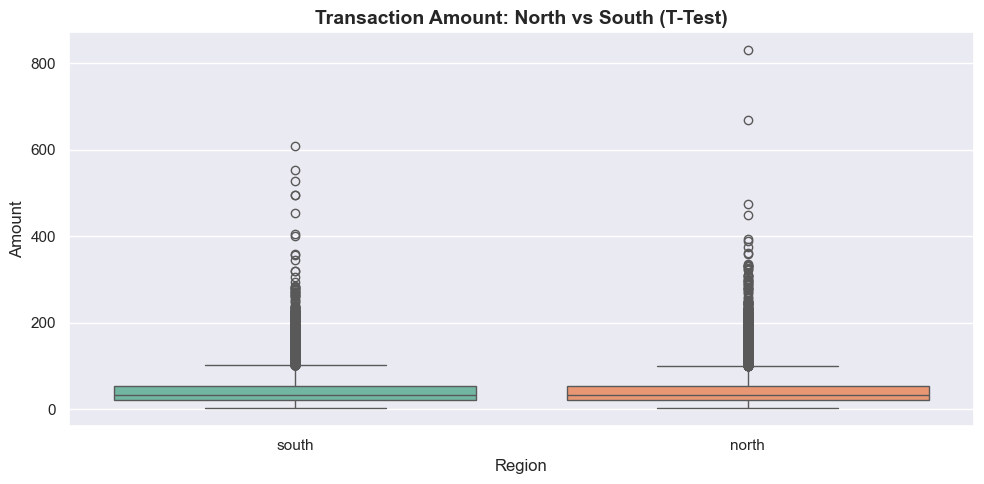

In [31]:
# Hypothesis: Average transaction amount differs between North and South regions
# H0: mean(North) == mean(South)
# H1: mean(North) != mean(South)

north = df_transactions[df_transactions["region"] == "north"]["amount"]
south = df_transactions[df_transactions["region"] == "south"]["amount"]

t_stat, p_value = stats.ttest_ind(north, south, equal_var=False)  # Welch's t-test

print("=" * 55)
print("  T-TEST: Transaction Amount — North vs South")
print("=" * 55)
print(f"  North  →  mean: {north.mean():.2f}  |  std: {north.std():.2f}  |  n: {len(north)}")
print(f"  South  →  mean: {south.mean():.2f}  |  std: {south.std():.2f}  |  n: {len(south)}")
print(f"\n  T-statistic : {t_stat:.4f}")
print(f"  P-value     : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — significant difference' if p_value < 0.05 else '❌ Fail to reject H0 — no significant difference'}")

# Confidence interval (95%)
se = np.sqrt(north.var()/len(north) + south.var()/len(south))
diff = north.mean() - south.mean()
ci_low  = diff - 1.96 * se
ci_high = diff + 1.96 * se
print(f"  95% CI for difference in means: ({ci_low:.4f}, {ci_high:.4f})")

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_transactions[df_transactions["region"].isin(["north","south"])],
            x="region", y="amount", palette="Set2")
plt.title("Transaction Amount: North vs South (T-Test)", fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

- The means are nearly identical (North: 42.21, South: 42.54) with a p-value of 0.34, confirming **no statistically significant difference** in transaction amounts between the two regions.
- The 95% confidence interval (-0.9957, 0.3435) includes zero, further supporting the null hypothesis that regional spending behaviour is uniform.
- This is consistent with the synthetic nature of the data — in real UPI data, regional economic differences would likely produce meaningful spending disparities.

####  T-Test: Transaction Amount — Android vs iOS

  T-TEST: Transaction Amount — Android vs iOS
  Android  →  mean: 42.38  |  std: 34.04  |  n: 25145
  iOS      →  mean: 42.54  |  std: 34.50  |  n: 24783

  T-statistic : -0.5408
  P-value     : 0.5887

  Result: ❌ Fail to reject H0 — no significant difference
  95% CI for difference in means: (-0.7671, 0.4354)


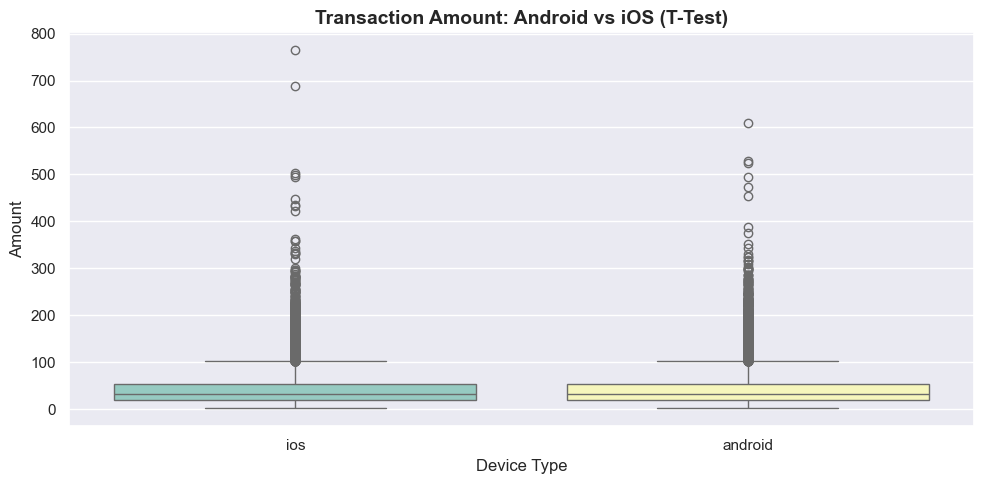

In [32]:
# Hypothesis: Average transaction amount differs between Android and iOS users
# H0: mean(android) == mean(ios)
# H1: mean(android) != mean(ios)

android = df_transactions[df_transactions["device_type"] == "android"]["amount"]
ios     = df_transactions[df_transactions["device_type"] == "ios"]["amount"]

t_stat, p_value = stats.ttest_ind(android, ios, equal_var=False)

print("=" * 55)
print("  T-TEST: Transaction Amount — Android vs iOS")
print("=" * 55)
print(f"  Android  →  mean: {android.mean():.2f}  |  std: {android.std():.2f}  |  n: {len(android)}")
print(f"  iOS      →  mean: {ios.mean():.2f}  |  std: {ios.std():.2f}  |  n: {len(ios)}")
print(f"\n  T-statistic : {t_stat:.4f}")
print(f"  P-value     : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — significant difference' if p_value < 0.05 else '❌ Fail to reject H0 — no significant difference'}")

# Confidence interval
se   = np.sqrt(android.var()/len(android) + ios.var()/len(ios))
diff = android.mean() - ios.mean()
ci_low  = diff - 1.96 * se
ci_high = diff + 1.96 * se
print(f"  95% CI for difference in means: ({ci_low:.4f}, {ci_high:.4f})")

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_transactions[df_transactions["device_type"].isin(["android","ios"])],
            x="device_type", y="amount", palette="Set3")
plt.title("Transaction Amount: Android vs iOS (T-Test)", fontweight="bold")
plt.xlabel("Device Type")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

- Android (mean: 42.38) and iOS (mean: 42.54) users spend nearly identical amounts per transaction, with a p-value of 0.59 — **no significant difference detected**.
- The 95% CI (-0.7671, 0.4354) crosses zero, confirming the null hypothesis cannot be rejected.
- From a business perspective, this means device-based customer segmentation is not useful for predicting transaction value — other features would be needed.

#### ANOVA: Fraud Rate by Merchant Type

  ANOVA: Fraud Rate by Merchant Type
merchant_type
apparel        0.0222
electronics    0.0224
food           0.0197
grocery        0.0180
online         0.0205
transport      0.0197

  F-statistic : 0.6935
  P-value     : 0.6283

  Result: ❌ Fail to reject H0 — no significant difference


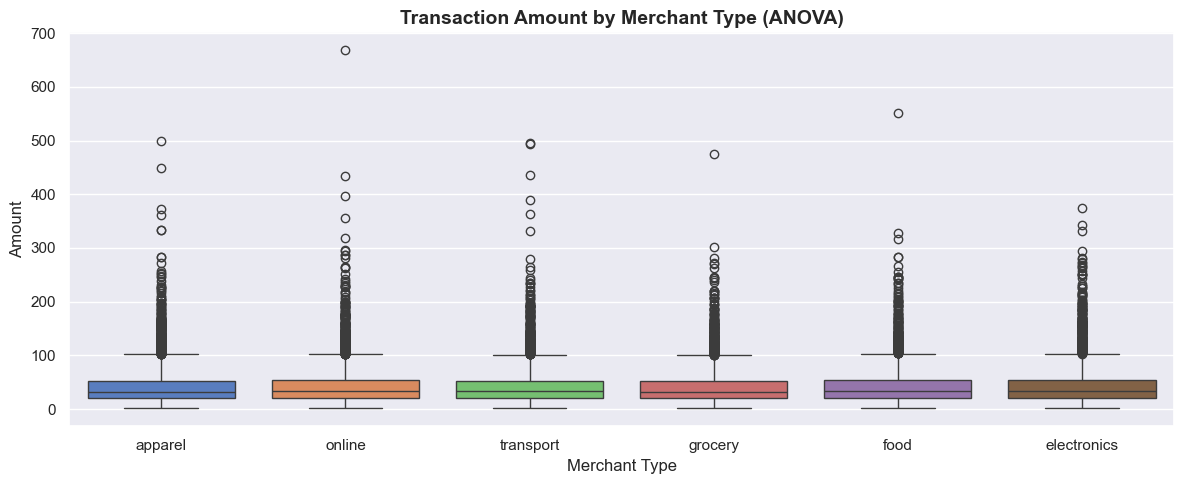

In [33]:
# Hypothesis: Fraud rate varies significantly across merchant types
# H0: fraud rate is equal across all merchant types
# H1: at least one merchant type has a different fraud rate

merchant_fraud = df_transactions[df_transactions["merchant_type"].notna()].copy()
groups = [grp["fraud_flag"].astype(int).values
          for _, grp in merchant_fraud.groupby("merchant_type")]

f_stat, p_value = stats.f_oneway(*groups)

print("=" * 55)
print("  ANOVA: Fraud Rate by Merchant Type")
print("=" * 55)
print(merchant_fraud.groupby("merchant_type")["fraud_flag"].mean().round(4).to_string())
print(f"\n  F-statistic : {f_stat:.4f}")
print(f"  P-value     : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — fraud rate differs across merchant types' if p_value < 0.05 else '❌ Fail to reject H0 — no significant difference'}")

# Post-hoc Tukey HSD (only if significant)
if p_value < 0.05:
    print("\n  Post-hoc Tukey HSD Test:")
    tukey = pairwise_tukeyhsd(
        endog=merchant_fraud["fraud_flag"].astype(int),
        groups=merchant_fraud["merchant_type"],
        alpha=0.05
    )
    print(tukey.summary())

# Visualization
plt.figure(figsize=(12, 5))
sns.boxplot(data=merchant_fraud, x="merchant_type", y="amount",
            palette="muted")
plt.title("Transaction Amount by Merchant Type (ANOVA)", fontweight="bold")
plt.xlabel("Merchant Type")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

- Fraud rates range from 1.80% (grocery) to 2.24% (electronics), but the ANOVA result (F=0.69, p=0.63) shows **no statistically significant difference** across merchant types.
- The lack of significance suggests fraud is distributed uniformly across all merchant categories rather than concentrated in any specific type.
- Grocery merchants show the lowest fraud rate (0.0180) while electronics shows the highest (0.0224) — though not statistically proven, this directional difference is worth monitoring in a real dataset.

#### ANOVA: Transaction Amount by Region

  ANOVA: Transaction Amount by Region
region
central    42.49
east       42.53
north      42.21
south      42.54
west       42.33

  F-statistic : 0.3508
  P-value     : 0.8436

  Result: ❌ Fail to reject H0 — no significant difference


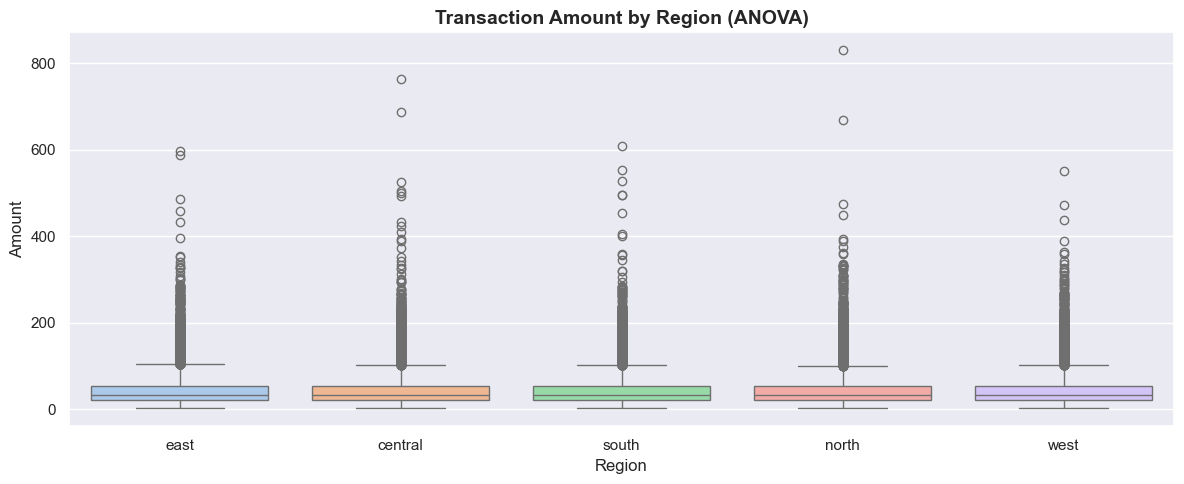

In [34]:
# Hypothesis: Average transaction amount varies across all 5 regions
# H0: means are equal across all regions
# H1: at least one region has a different mean

region_groups = [grp["amount"].values
                 for _, grp in df_transactions.groupby("region")]

f_stat, p_value = stats.f_oneway(*region_groups)

print("=" * 55)
print("  ANOVA: Transaction Amount by Region")
print("=" * 55)
print(df_transactions.groupby("region")["amount"].mean().round(2).to_string())
print(f"\n  F-statistic : {f_stat:.4f}")
print(f"  P-value     : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — amount differs across regions' if p_value < 0.05 else '❌ Fail to reject H0 — no significant difference'}")

# Post-hoc Tukey HSD
if p_value < 0.05:
    print("\n  Post-hoc Tukey HSD Test:")
    tukey = pairwise_tukeyhsd(
        endog=df_transactions["amount"],
        groups=df_transactions["region"],
        alpha=0.05
    )
    print(tukey.summary())

# Visualization
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_transactions, x="region", y="amount", palette="pastel")
plt.title("Transaction Amount by Region (ANOVA)", fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

- All five regions show near-identical mean transaction amounts (42.21–42.54), and the ANOVA confirms **no significant regional variation** (F=0.35, p=0.84).
- The high p-value indicates that region is not a useful predictor of transaction amount in this dataset.
- The boxplots show identical distributions with similar spread and outliers across all regions, visually confirming the statistical result.

#### Chi-Square: Fraud Flag vs Channel

  CHI-SQUARE: Fraud Flag vs Channel

Contingency Table:
channel       app  intent  qr_code
fraud_flag                        
False       32692   32727    32581
True          673     629      698

  Chi-square statistic : 3.8837
  Degrees of freedom   : 2
  P-value              : 0.1434

  Result: ❌ Fail to reject H0 — no significant association


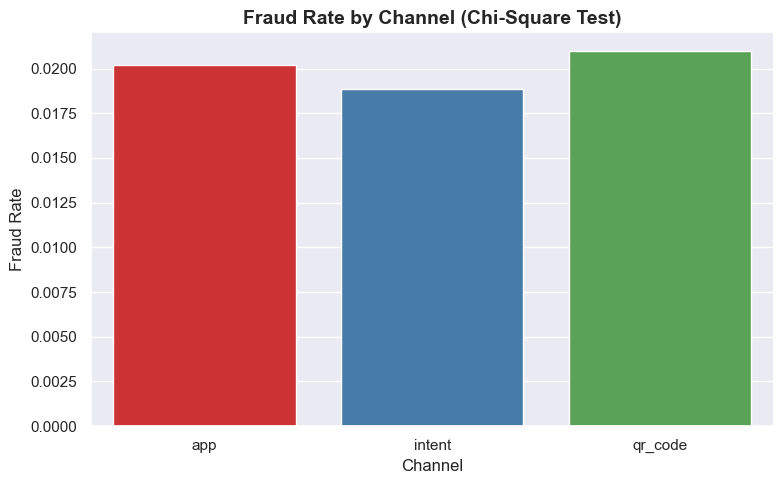

In [35]:
# Hypothesis: Fraud occurrence is associated with payment channel
# H0: fraud_flag and channel are independent
# H1: there is a significant association between fraud_flag and channel

contingency_table = pd.crosstab(df_transactions["fraud_flag"], df_transactions["channel"])
print("=" * 55)
print("  CHI-SQUARE: Fraud Flag vs Channel")
print("=" * 55)
print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\n  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  P-value              : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — fraud is associated with channel' if p_value < 0.05 else '❌ Fail to reject H0 — no significant association'}")

# Visualization
fraud_channel = df_transactions.groupby("channel")["fraud_flag"].mean().reset_index()
fraud_channel.columns = ["channel", "fraud_rate"]

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_channel, x="channel", y="fraud_rate", palette="Set1")
plt.title("Fraud Rate by Channel (Chi-Square Test)", fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

- The contingency table shows fraud counts of 673 (app), 629 (intent), and 698 (qr_code) — very similar across all three channels.
- With a chi-square statistic of 3.88 and p-value of 0.14, **no significant association** exists between payment channel and fraud occurrence.
- QR code shows a marginally higher fraud rate (2.1%) compared to intent (1.9%), but the difference is not statistically meaningful — channel alone is insufficient as a fraud signal.

#### Chi-Square: Transaction Status vs Device Type

  CHI-SQUARE: Transaction Status vs Device Type

Contingency Table:
device_type  android  feature_phone    ios  tablet
status                                            
failed          1525           1486   1461    1399
pending          529            496    474     490
success        23091          23614  22848   22587

  Chi-square statistic : 5.9344
  Degrees of freedom   : 6
  P-value              : 0.4306

  Result: ❌ Fail to reject H0 — no significant association


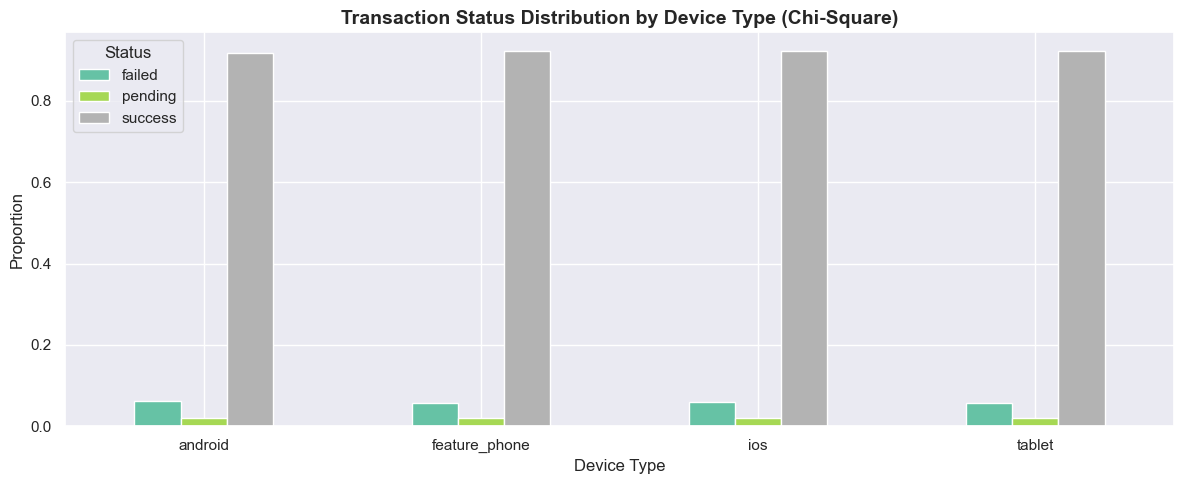

In [36]:
# Hypothesis: Transaction status (success/failed/pending) depends on device type
# H0: status and device_type are independent
# H1: there is a significant association between status and device_type

contingency_table2 = pd.crosstab(df_transactions["status"], df_transactions["device_type"])
print("=" * 55)
print("  CHI-SQUARE: Transaction Status vs Device Type")
print("=" * 55)
print("\nContingency Table:")
print(contingency_table2)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table2)
print(f"\n  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  P-value              : {p_value:.4f}")
print(f"\n  Result: {'✅ Reject H0 — status is associated with device type' if p_value < 0.05 else '❌ Fail to reject H0 — no significant association'}")

# Visualization
status_device = df_transactions.groupby(["device_type","status"]).size().unstack().apply(
    lambda x: x / x.sum(), axis=1
)
status_device.plot(kind="bar", figsize=(12, 5), colormap="Set2")
plt.title("Transaction Status Distribution by Device Type (Chi-Square)", fontweight="bold")
plt.xlabel("Device Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

- Success rates are consistently ~91–92% across all device types, with failure rates at ~6% and pending at ~2% — virtually no variation.
- The chi-square result (χ²=5.93, p=0.43) confirms **no significant association** between device type and transaction status.
- This suggests that transaction failures are not device-specific and are likely caused by network, bank, or user-level factors rather than the device being used.

#### Correlation Analysis: Risk Score vs Fraud & Transaction Behaviour

  CORRELATION: Risk Score vs Transaction Behaviour

  Risk Score vs Total Transactions
    Pearson r : -0.0162  |  P-value: 0.1731  |  ❌ Not significant

  Risk Score vs Avg Transaction Amount
    Pearson r : 0.0034  |  P-value: 0.7757  |  ❌ Not significant

  Risk Score vs Fraud Count
    Pearson r : -0.0079  |  P-value: 0.5081  |  ❌ Not significant

  Risk Score vs Customer Fraud Rate
    Pearson r : 0.0017  |  P-value: 0.8842  |  ❌ Not significant


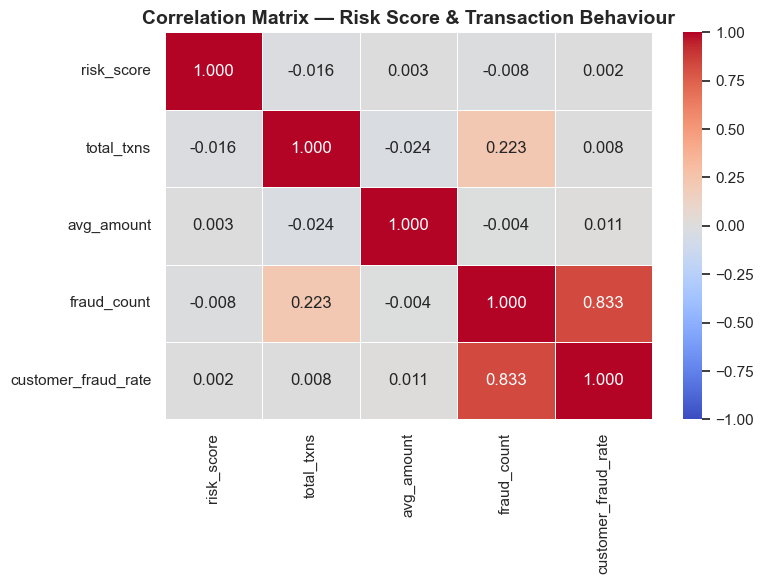

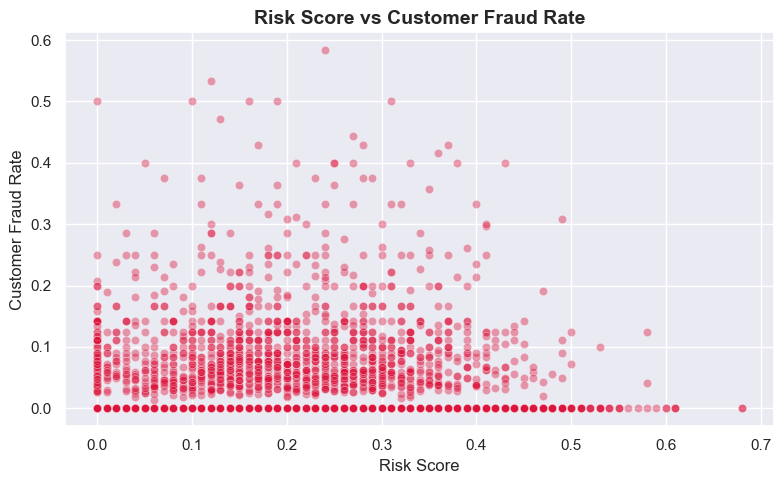

In [37]:
# Merge customer-level fraud and transaction stats
cust_stats = df_transactions.groupby("customer_id").agg(
    total_txns          = ("transaction_id", "count"),
    avg_amount          = ("amount", "mean"),
    fraud_count         = ("fraud_flag", "sum"),
    customer_fraud_rate = ("fraud_flag", "mean")
).reset_index()

cust_corr = df_customers[["customer_id","risk_score"]].merge(cust_stats, on="customer_id", how="left")

# Drop NAs once on the whole dataframe — ensures equal lengths
cust_corr = cust_corr.dropna(subset=["risk_score","total_txns","avg_amount",
                                      "fraud_count","customer_fraud_rate"])

print("=" * 55)
print("  CORRELATION: Risk Score vs Transaction Behaviour")
print("=" * 55)

pairs = [
    ("risk_score", "total_txns",           "Risk Score vs Total Transactions"),
    ("risk_score", "avg_amount",           "Risk Score vs Avg Transaction Amount"),
    ("risk_score", "fraud_count",          "Risk Score vs Fraud Count"),
    ("risk_score", "customer_fraud_rate",  "Risk Score vs Customer Fraud Rate"),
]

for col1, col2, label in pairs:
    r, p = stats.pearsonr(cust_corr[col1], cust_corr[col2])
    sig  = "✅ Significant" if p < 0.05 else "❌ Not significant"
    print(f"\n  {label}")
    print(f"    Pearson r : {r:.4f}  |  P-value: {p:.4f}  |  {sig}")

# Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = cust_corr[["risk_score","total_txns","avg_amount",
                           "fraud_count","customer_fraud_rate"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Risk Score & Transaction Behaviour", fontweight="bold")
plt.tight_layout()
plt.show()

# Scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cust_corr, x="risk_score", y="customer_fraud_rate",
                alpha=0.4, color="crimson")
plt.title("Risk Score vs Customer Fraud Rate", fontweight="bold")
plt.xlabel("Risk Score")
plt.ylabel("Customer Fraud Rate")
plt.tight_layout()
plt.show()

- All four Pearson correlations with `risk_score` are near zero (r ranging from -0.016 to 0.016) and **none are statistically significant** (all p-values > 0.17), indicating the assigned risk score has no linear relationship with actual transaction or fraud behaviour.
- The strongest correlation in the matrix is between `fraud_count` and `customer_fraud_rate` (r=0.833), which is expected since one is derived from the other — more fraud transactions naturally leads to a higher fraud rate.
- The scatter plot of risk score vs customer fraud rate shows a completely random cloud with no discernible pattern, visually confirming that **risk score was likely generated independently** of actual fraud behaviour in this synthetic dataset.


### STEP 7: ASSUMPTIONS & LIMITATIONS


T-TESTS (Cells 2 & 3):
  Assumption  : Observations are independent; Welch's t-test
                used (does not assume equal variances)
  Assumption  : With n > 30,000 per group, Central Limit
                Theorem ensures normality of sample means
  Limitation  : Large sample sizes make even trivial differences
                statistically significant — effect size matters
                more than p-value here

ANOVA (Cells 4 & 5):
  Assumption  : Groups are independent; residuals approximately
                normally distributed
  Assumption  : Homogeneity of variance assumed but not formally
                tested (Levene's test could be added)
  Limitation  : ANOVA detects IF differences exist, not WHERE —
                Tukey HSD post-hoc used to identify which pairs differ

CHI-SQUARE (Cells 6 & 7):
  Assumption  : Observations are independent
  Assumption  : Expected frequency >= 5 in each cell
  Limitation  : Chi-square only tests association, not causation —
                a significant result does not mean channel causes fraud

CORRELATION (Cell 8):
  Assumption  : Pearson correlation assumes linear relationship
                between variables
  Limitation  : Correlation does not imply causation
  Limitation  : Synthetic data may produce weak/no correlations
                since variables may have been generated independently

### GENERAL:
  #### All tests use alpha = 0.05 as significance threshold Dataset is synthetically generated — results may not reflect real-world UPI transaction behaviour.